# Sesión 2 Apartado 1: Modelos Supervisados

Objetivo: Presentar modelos de clasificación binaria: Regresión logística, Random Forest, SVM y KNN. Cada sección incluye una breve explicación, implementación y una pequeña prueba.

In [24]:
# Imports y generación de dataset
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print('Shapes:', X_train.shape, X_test.shape)

Shapes: (700, 2) (300, 2)


## Regresión Logística

Modelo lineal para clasificación probabilística. Predice la probabilidad de la clase positiva mediante la función sigmoide; la decisión se toma con un umbral (p.ej. 0.5). Es un buen baseline: rápido, interpretable (coeficientes) y funciona bien cuando la relación entre features y la etiqueta es aproximadamente lineal.

Pros: interpretable, eficiente, pocos hiperparámetros. 
Contras: no captura fácilmente relaciones no lineales sin transformar features.

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print('Accuracy (Logistic Regression):', accuracy_score(y_test, y_pred))

Accuracy (Logistic Regression): 0.8966666666666666


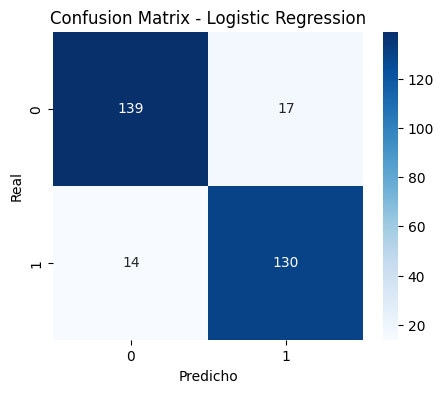

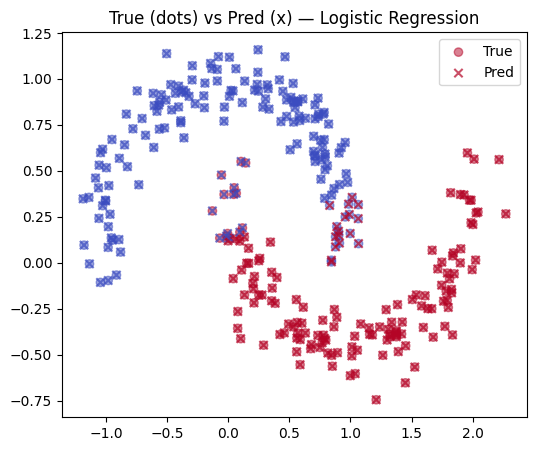

Accuracy (Logistic Regression): 0.8966666666666666


In [26]:
# Visualización: Logistic Regression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

# Predicciones ya calculadas como y_pred en la celda anterior
# En caso de ser re-ejecutado, recomputar:
y_pred_lr = lr.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

# PCA 2D para visualizar predicciones
plt.figure(figsize=(6,5))
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap='coolwarm', alpha=0.5, label='True')
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred_lr, cmap='coolwarm', marker='x', alpha=0.7, label='Pred')
plt.title('True (dots) vs Pred (x) — Logistic Regression')
plt.legend(['True','Pred'])
plt.show()

print('Accuracy (Logistic Regression):', accuracy_score(y_test, y_pred_lr))

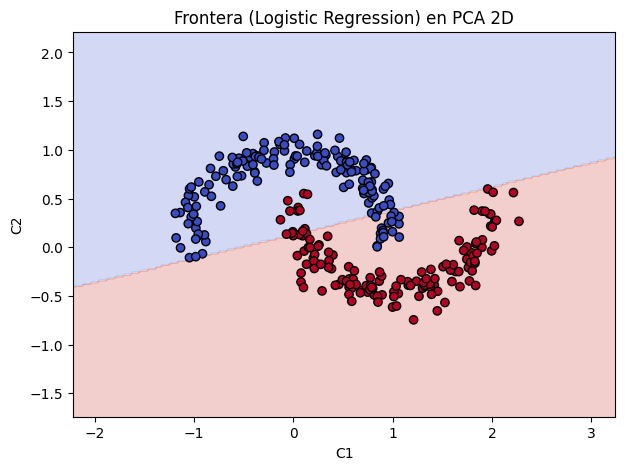

In [27]:
# Frontera de decisión — Logistic Regression (visualización en PCA 2D)
import numpy as np
import matplotlib.pyplot as plt

# Crear malla
x_min, x_max = X_train[:,0].min() - 1, X_train[:,0].max() + 1
y_min, y_max = X_train[:,1].min() - 1, X_train[:,1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = lr.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap='coolwarm', edgecolor='k')
plt.title('Frontera (Logistic Regression) en PCA 2D')
plt.xlabel('C1')
plt.ylabel('C2')
plt.show()

# Notas: entrenamos un modelo sobre la proyección PCA para visualizar una aproximación de la frontera.

## Random Forest

Ensamble de árboles de decisión mediante bagging. Construye muchos árboles sobre muestras diferentes del entrenamiento y promedia sus predicciones. Reduce la varianza frente a un árbol único y maneja relaciones no lineales y interacciones entre variables.

Pros: robusto, maneja datos heterogéneos, poca preparación de features, ofrece importancia de features.
Contras: menos interpretable que un árbol único, puede ser más lento y usar más memoria.

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=3)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print('Accuracy (Random Forest):', accuracy_score(y_test, y_pred))

Accuracy (Random Forest): 0.9433333333333334


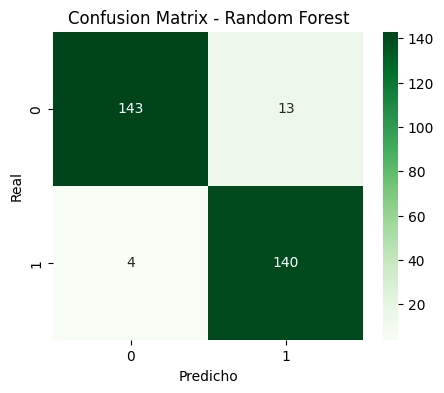

Accuracy (Random Forest): 0.9433333333333334


In [29]:
# Visualización: Random Forest
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

# Predicciones rf
y_pred_rf = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

print('Accuracy (Random Forest):', accuracy_score(y_test, y_pred_rf))

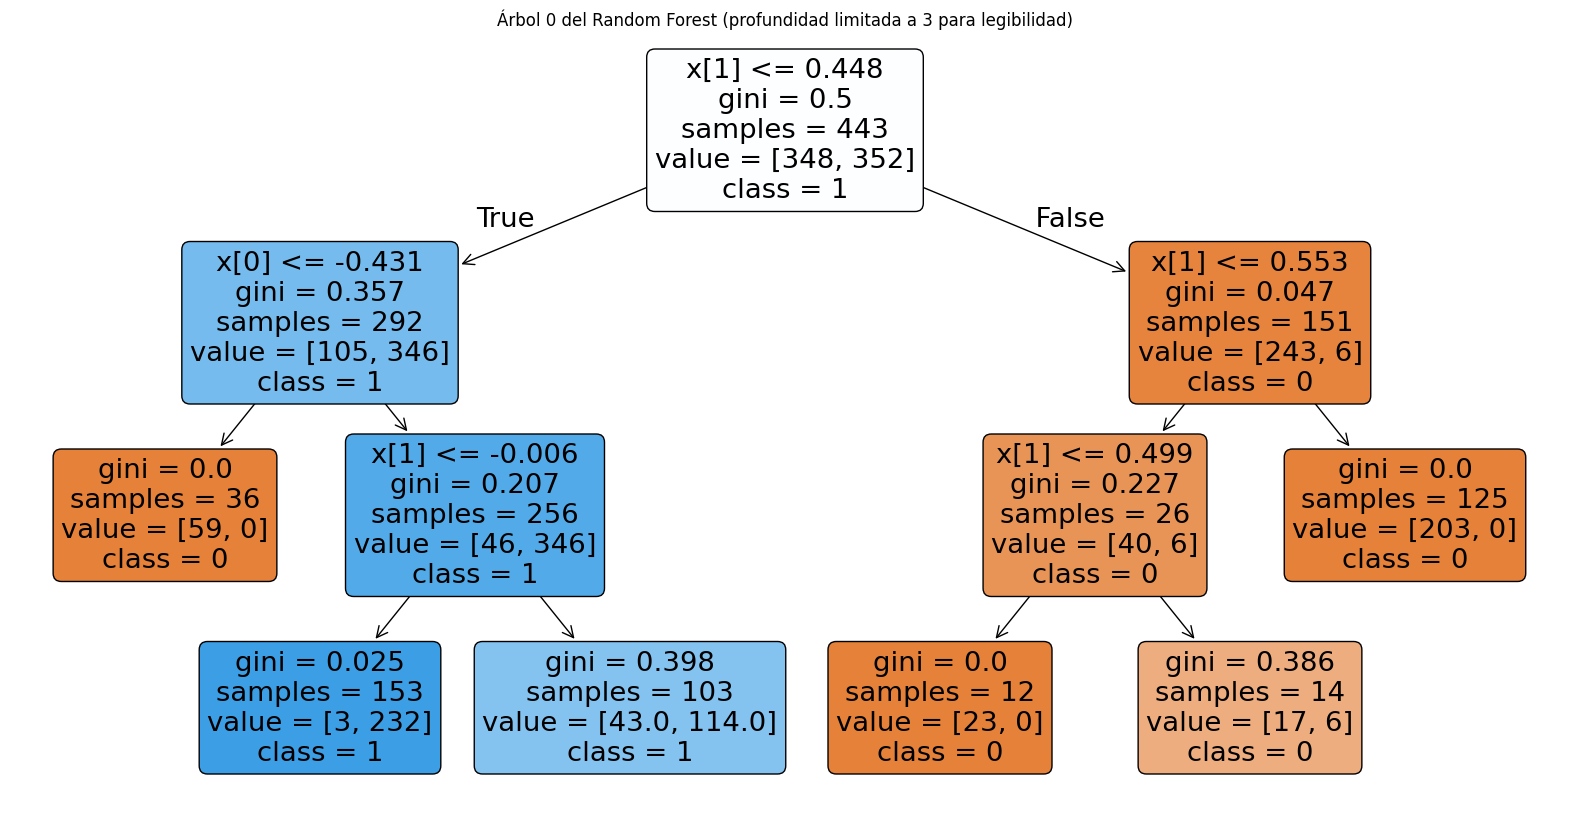

Muestra 98: hoja: 10
Nodo recorrido: [ 0  6 10]
---
Muestra 296: hoja: 10
Nodo recorrido: [ 0  6 10]
---
Muestra 146: hoja: 5
Nodo recorrido: [0 1 3 5]
---
Muestra 226: hoja: 10
Nodo recorrido: [ 0  6 10]
---
Muestra 12: hoja: 5
Nodo recorrido: [0 1 3 5]
---
Reglas (resumidas, max_depth=3):

|--- feature_1 <= 0.45
|   |--- feature_0 <= -0.43
|   |   |--- class: 0.0
|   |--- feature_0 >  -0.43
|   |   |--- feature_1 <= -0.01
|   |   |   |--- class: 1.0
|   |   |--- feature_1 >  -0.01
|   |   |   |--- class: 1.0
|--- feature_1 >  0.45
|   |--- feature_1 <= 0.55
|   |   |--- feature_1 <= 0.50
|   |   |   |--- class: 0.0
|   |   |--- feature_1 >  0.50
|   |   |   |--- class: 0.0
|   |--- feature_1 >  0.55
|   |   |--- class: 0.0



In [30]:
# Visualización adicional: árbol individual y decision paths (Random Forest)
from sklearn import tree
import matplotlib.pyplot as plt
import numpy as np

# Selecciona el estimador 0 del ensemble
estimator = rf.estimators_[0]

# Plot del árbol (puede ser grande)
plt.figure(figsize=(20,10))
tree.plot_tree(estimator, filled=True, rounded=True, feature_names=None, class_names=['0','1'], max_depth=3)
plt.title('Árbol 0 del Random Forest (profundidad limitada a 3 para legibilidad)')
plt.show()

# Decision path para algunas muestras de X_test
sample_idx = np.random.choice(np.arange(X_test.shape[0]), size=5, replace=False)
paths = estimator.decision_path(X_test[sample_idx])

for i, idx in enumerate(sample_idx):
    node_indicator = estimator.decision_path(X_test[idx].reshape(1, -1))
    leave_id = estimator.apply(X_test[idx].reshape(1, -1))
    print(f"Muestra {idx}: hoja: {leave_id[0]}")
    # nodes touched
    node_index = node_indicator.indices[node_indicator.indptr[0]:node_indicator.indptr[1]]
    print('Nodo recorrido:', node_index)
    print('---')

# Nota: para ver visualmente todos los nodos y reglas se puede usar export_text
from sklearn.tree import export_text
r = export_text(estimator, max_depth=3)
print('Reglas (resumidas, max_depth=3):\n')
print(r)

## SVM

Busca el hiperplano que maximiza el margen entre clases. Con el "kernel trick" puede separar datos no lineales proyectándolos a espacios de mayor dimensión.

Pros: eficaz en espacios de alta dimensión, flexible con kernels.
Contras: sensible a la escala de features, puede ser lento en datasets grandes y requiere ajustar el parámetro C y el kernel.

In [31]:
from sklearn.svm import SVC

svm = SVC(probability=True)
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)
print('Accuracy (SVM):', accuracy_score(y_test, y_pred))

Accuracy (SVM): 1.0


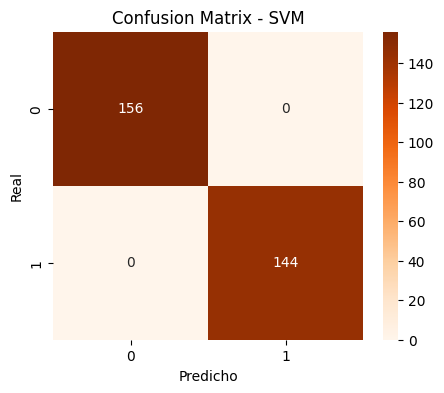

Accuracy (SVM): 1.0


In [32]:
# Visualización: SVM
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

# Predicciones svm
y_pred_svm = svm.predict(X_test)

cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

print('Accuracy (SVM):', accuracy_score(y_test, y_pred_svm))

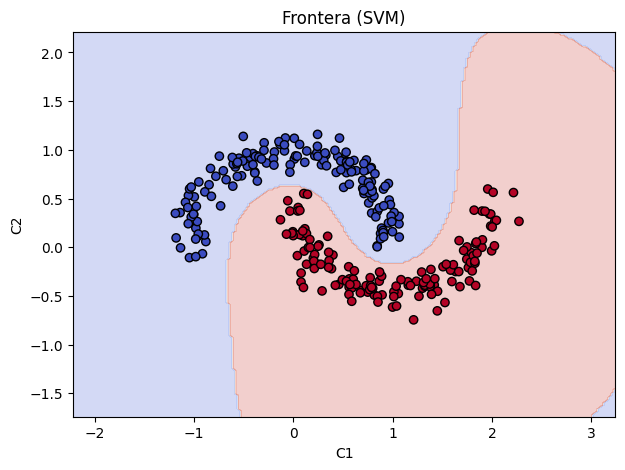

In [33]:
# Frontera de decisión — SVM (visualización en PCA 2D)
import numpy as np
import matplotlib.pyplot as plt


# Crear malla
x_min, x_max = X_train[:,0].min() - 1, X_train[:,0].max() + 1
y_min, y_max = X_train[:,1].min() - 1, X_train[:,1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap='coolwarm', edgecolor='k')
plt.title('Frontera (SVM)')
plt.xlabel('C1')
plt.ylabel('C2')
plt.show()

# Notas: entrenamos un SVM sobre la proyección PCA para visualizar la frontera en 2D.


## KNN

Para predecir, busca los k vecinos más próximos en el conjunto de entrenamiento y asigna la clase por mayoría. Es un método "lazy" (no hay entrenamiento real).

Pros: simple, no asume forma de la frontera de decisión.
Contras: sensible a la escala y a ruido, puede ser lento en predicción para datasets grandes y requiere elección de k y de la métrica de distancia.

In [34]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print('Accuracy (KNN):', accuracy_score(y_test, y_pred))

Accuracy (KNN): 1.0


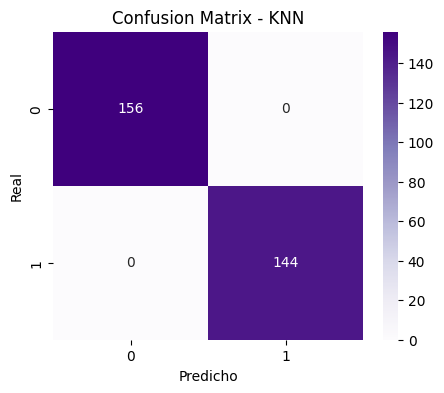

Accuracy (KNN): 1.0


In [35]:
# Visualización: KNN
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

# Predicciones knn
y_pred_knn = knn.predict(X_test)

cm = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

print('Accuracy (KNN):', accuracy_score(y_test, y_pred_knn))

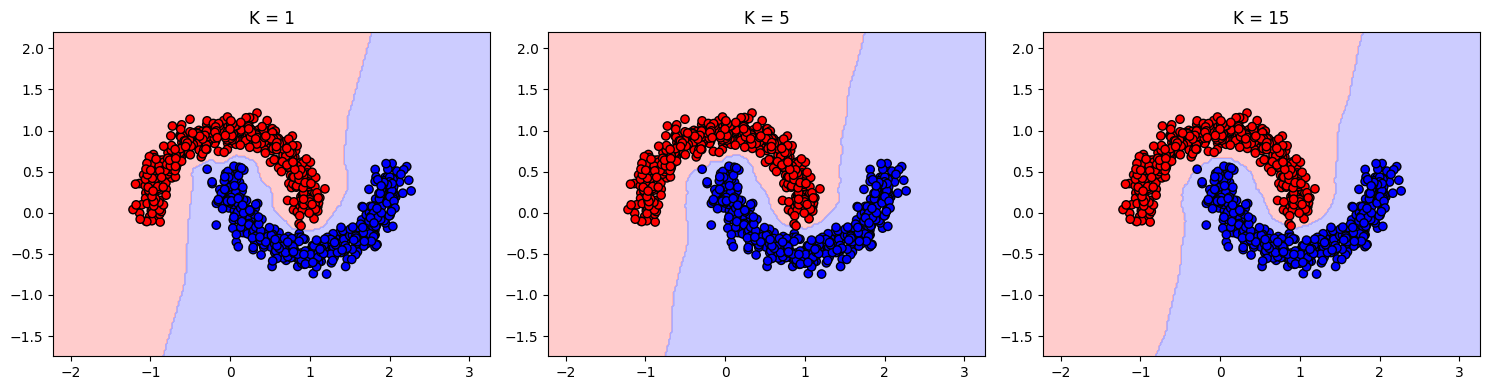

In [36]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

# Configuración del grid para la visualización
h = 0.02  # tamaño del paso en la malla
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Crear la figura con distintos valores de K
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, k in enumerate([1, 5, 15]):
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X, y)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    axes[idx].contourf(
        xx, yy, Z, cmap=ListedColormap(["#FFAAAA", "#AAAAFF"]), alpha=0.6
    )
    axes[idx].scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        cmap=ListedColormap(["#FF0000", "#0000FF"]),
        edgecolor="k",
    )
    axes[idx].set_title(f"K = {k}")

plt.tight_layout()
plt.show()

## Oversampling y Undersampling

Original dataset shape: Counter({np.int64(0): 900, np.int64(1): 100})


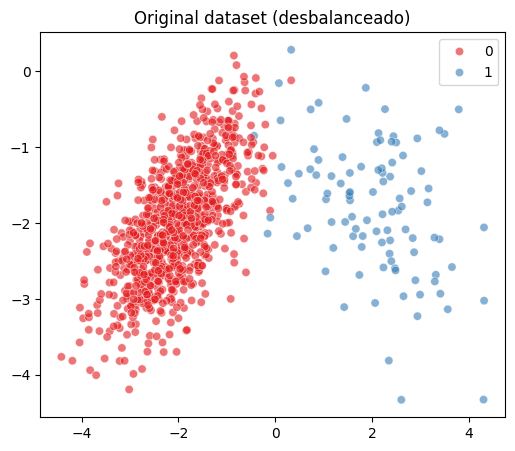

In [37]:
# Vamos a realizar oversampling y undersampling con imbalanced-learn
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Crear un dataset desbalanceado
X, y = make_classification(n_classes=2, class_sep=2,
                           weights=[0.9, 0.1], n_informative=3,
                           n_redundant=1, flip_y=0,
                           n_features=5, n_clusters_per_class=1,
                           n_samples=1000, random_state=10)
print('Original dataset shape:', Counter(y))
# Visualización del dataset original
plt.figure(figsize=(6,5))
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y, palette='Set1', alpha=0.6)
plt.title('Original dataset (desbalanceado)')
plt.show()

Resampled dataset shape (oversampling): Counter({np.int64(0): 900, np.int64(1): 900})


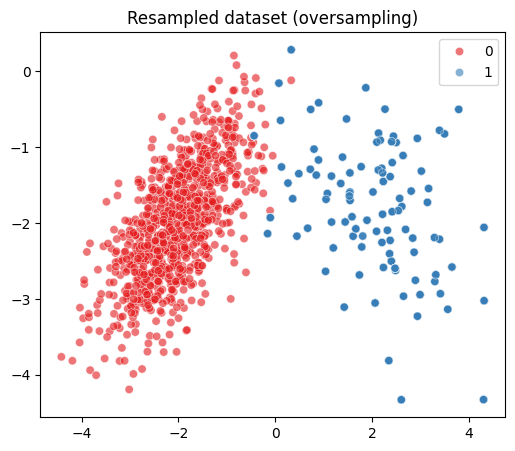

In [38]:
# Aplicar oversampling
ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X, y)
print("Resampled dataset shape (oversampling):", Counter(y_res))
# Visualización del dataset re-muestreado
plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_res[:, 0], y=X_res[:, 1], hue=y_res, palette="Set1", alpha=0.6)
plt.title("Resampled dataset (oversampling)")
plt.show()

Resampled dataset shape (undersampling): Counter({np.int64(0): 100, np.int64(1): 100})


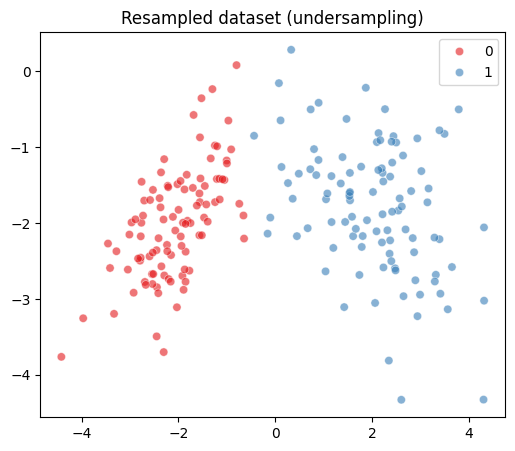

In [39]:
# Aplicar undersampling
rus = RandomUnderSampler(random_state=42)
X_res_u, y_res_u = rus.fit_resample(X, y)
print("Resampled dataset shape (undersampling):", Counter(y_res_u))
# Visualización del dataset re-muestreado
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x=X_res_u[:, 0], y=X_res_u[:, 1], hue=y_res_u, palette="Set1", alpha=0.6
)
plt.title("Resampled dataset (undersampling)")
plt.show()

### Alternativa nativa en Scikit-Learn: `class_weight='balanced'`

Una alternativa muy eficiente al remuestreo (sin necesidad de crear datos sintéticos ni eliminar filas) es el parámetro `class_weight='balanced'`, disponible en la mayoría de clasificadores de Scikit-Learn (`LogisticRegression`, `RandomForestClassifier`, `SVC`, etc.).

Este parámetro ajusta automáticamente los pesos de la función de coste de forma inversamente proporcional a la frecuencia de cada clase, penalizando con mayor rigor los errores en la clase minoritaria.

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Dividimos el dataset desbalanceado generado anteriormente
X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 1. Regresión Logística estándar vs con class_weight='balanced'
lr_standard = LogisticRegression(random_state=42)
lr_standard.fit(X_train_imb, y_train_imb)
y_pred_standard = lr_standard.predict(X_test_imb)

lr_balanced = LogisticRegression(class_weight='balanced', random_state=42)
lr_balanced.fit(X_train_imb, y_train_imb)
y_pred_balanced = lr_balanced.predict(X_test_imb)

print("=== Regresión Logística ESTÁNDAR (sin ponderar) ===")
print(classification_report(y_test_imb, y_pred_standard, target_names=['Mayoritaria (0)', 'Minoritaria (1)']))

print("=== Regresión Logística con class_weight='balanced' ===")
print(classification_report(y_test_imb, y_pred_balanced, target_names=['Mayoritaria (0)', 'Minoritaria (1)']))

# 2. También aplicable a Random Forest
rf_balanced = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_balanced.fit(X_train_imb, y_train_imb)
y_pred_rf_bal = rf_balanced.predict(X_test_imb)
print("=== Random Forest con class_weight='balanced' (F1 clase minoritaria):", 
      classification_report(y_test_imb, y_pred_rf_bal, target_names=['0', '1'], output_dict=True)['1']['f1-score'])

=== Regresión Logística ESTÁNDAR (sin ponderar) ===
                 precision    recall  f1-score   support

Mayoritaria (0)       0.99      1.00      0.99       270
Minoritaria (1)       1.00      0.90      0.95        30

       accuracy                           0.99       300
      macro avg       0.99      0.95      0.97       300
   weighted avg       0.99      0.99      0.99       300

=== Regresión Logística con class_weight='balanced' ===
                 precision    recall  f1-score   support

Mayoritaria (0)       0.99      1.00      0.99       270
Minoritaria (1)       0.97      0.93      0.95        30

       accuracy                           0.99       300
      macro avg       0.98      0.96      0.97       300
   weighted avg       0.99      0.99      0.99       300

=== Random Forest con class_weight='balanced' (F1 clase minoritaria): 0.9655172413793104


## Multiclase

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score


iris = load_iris()
X, y = iris.data, iris.target

clf = LogisticRegression(solver="lbfgs", max_iter=200)
clf.fit(X, y)

y_pred = clf.predict(X)
print("Accuracy (KNN):", accuracy_score(y, y_pred))

Accuracy (KNN): 0.9733333333333334


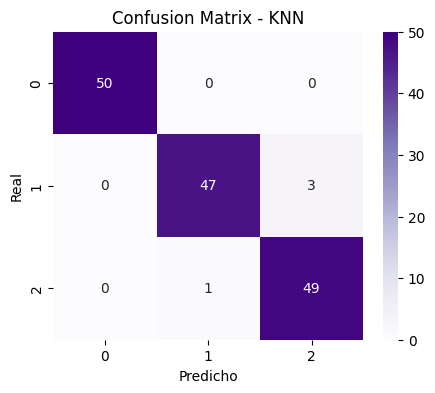

In [42]:
cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

La **regresión softmax** es una extensión de la regresión logística al caso multiclase.  
En lugar de predecir solo dos clases (0 o 1), ahora podemos predecir $K$ clases distintas.

El modelo asigna a cada clase $k$ una probabilidad:

$$
P(y = k \mid x) = \frac{e^{w_k^\top x + b_k}}{\sum_{j=1}^{K} e^{w_j^\top x + b_j}}
$$

donde:
- $x$ = vector de características de entrada.
- $w_k$ = vector de pesos asociado a la clase $k$.
- $b_k$ = sesgo asociado a la clase $k$.
- $K$ = número total de clases.

Esto significa que cada clase tiene su propio conjunto de parámetros $(w_k, b_k)$.

#### Parámetros del modelo
- **Pesos $W$:** una matriz de tamaño $[K \times d]$, donde $d$ es la dimensión de las características.
- **Sesgos $b$:** un vector de tamaño $[K]$.
- En total, el modelo aprende $K \times d + K$ parámetros.

#### Función de pérdida
La más utilizada es la **entropía cruzada**:

$$
J(\theta) = - \frac{1}{N} \sum_{i=1}^{N} \sum_{k=1}^{K} \mathbf{1}\{y_i = k\} \cdot \log P(y_i = k \mid x_i)
$$

donde $\mathbf{1}\{y_i = k\}$ es un indicador que vale 1 si el ejemplo $i$ pertenece a la clase $k$, y 0 en caso contrario.

Esta función mide qué tan bien las probabilidades predichas se ajustan a las clases reales.


In [43]:
print("Dimensión de W:", clf.coef_.shape)  # (K, d)
print("W (pesos):\n", clf.coef_)
print("\nDimensión de b:", clf.intercept_.shape)  # (K,)
print("b (sesgos):\n", clf.intercept_)

Dimensión de W: (3, 4)
W (pesos):
 [[-0.419879    0.96688243 -2.51902726 -1.08452051]
 [ 0.53159996 -0.31512045 -0.20365353 -0.94303732]
 [-0.11172097 -0.65176199  2.72268079  2.02755783]]

Dimensión de b: (3,)
b (sesgos):
 [  9.83967638   2.22411194 -12.06378832]


### Descenso por Gradiente

Cuando entrenamos un modelo, definimos una **función de pérdida** (*loss function*) que mide qué tan mal está prediciendo el modelo.  
El objetivo del entrenamiento es **ajustar los parámetros** (los pesos $W$ y los sesgos $b$) para minimizar esa pérdida.

El **descenso por gradiente** es un algoritmo iterativo que:

1. Calcula la **derivada (gradiente)** de la función de pérdida con respecto a los parámetros.
2. Ajusta los parámetros en la dirección opuesta al gradiente, ya que esa es la dirección de descenso más rápido.

$$
\theta \leftarrow \theta - \eta \cdot \nabla_\theta J(\theta)
$$

donde:
- $\theta$: parámetros del modelo ($W, b$)  
- $J(\theta)$: función de pérdida  
- $\nabla_\theta J(\theta)$: gradiente de la pérdida respecto a los parámetros  
- $\eta$: tasa de aprendizaje (*learning rate*)  

Este proceso se repite hasta que la función de pérdida se estabiliza (mínimo local o global).

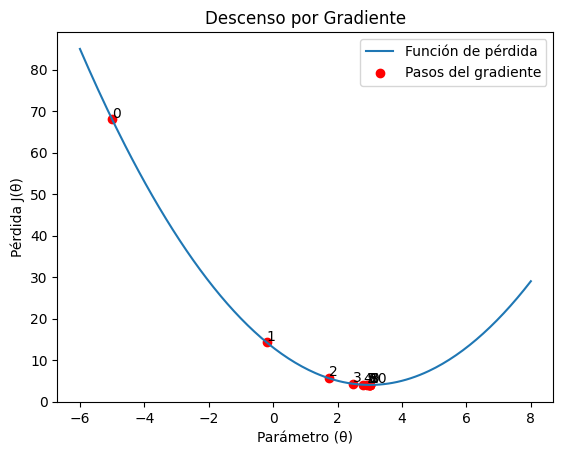

In [44]:
import numpy as np
import matplotlib.pyplot as plt


# Función de pérdida de ejemplo (convexa)
def loss(x):
    return (x - 3) ** 2 + 4


# Derivada de la función de pérdida
def grad(x):
    return 2 * (x - 3)


# Descenso por gradiente
x = -5  # valor inicial
lr = 0.3
history = [x]

for _ in range(10):
    x = x - lr * grad(x)
    history.append(x)

# Graficar
xs = np.linspace(-6, 8, 200)
ys = loss(xs)

plt.plot(xs, ys, label="Función de pérdida")
plt.scatter(
    history,
    [loss(h) for h in history],
    c="red",
    marker="o",
    label="Pasos del gradiente",
)
for i, h in enumerate(history):
    plt.text(h, loss(h) + 0.5, str(i))
plt.xlabel("Parámetro (θ)")
plt.ylabel("Pérdida J(θ)")
plt.title("Descenso por Gradiente")
plt.legend()
plt.show()

### Funciones de Activación

En los modelos lineales (como la regresión lineal), la salida es una combinación lineal de las entradas:

$$
z = w^\top x + b
$$

El problema es que una función **puramente lineal** no puede capturar relaciones complejas entre las variables.

Aquí entran en juego las **funciones de activación**: transformaciones no lineales que aplicamos a la salida $z$.  
Estas funciones permiten que el modelo aprenda relaciones más ricas.

#### Ejemplos de funciones de activación:

- **Sigmoide**  
  Transforma un valor real en una probabilidad entre 0 y 1.  
  Se usa en **regresión logística binaria**.

  $$
  \sigma(z) = \frac{1}{1 + e^{-z}}
  $$

- **Softmax**  
  Generaliza la sigmoide al caso multiclase, transformando un vector en una distribución de probabilidades.  
  Se usa en **regresión softmax** y en la capa de salida de redes neuronales para clasificación.

  $$
  \text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^K e^{z_j}}
  $$

- **ReLU (Rectified Linear Unit)**  
  Muy usada en redes neuronales modernas.

  $$
  \text{ReLU}(z) = \max(0, z)
  $$

  Permite introducir no linealidad y es más eficiente en el entrenamiento que la sigmoide.

#### Intuición
- Las funciones de activación hacen que las redes neuronales puedan "doblar" el espacio de representación.  
- Sin ellas, apilar capas sería equivalente a una sola transformación lineal (es decir, seguiríamos en el mismo plano).


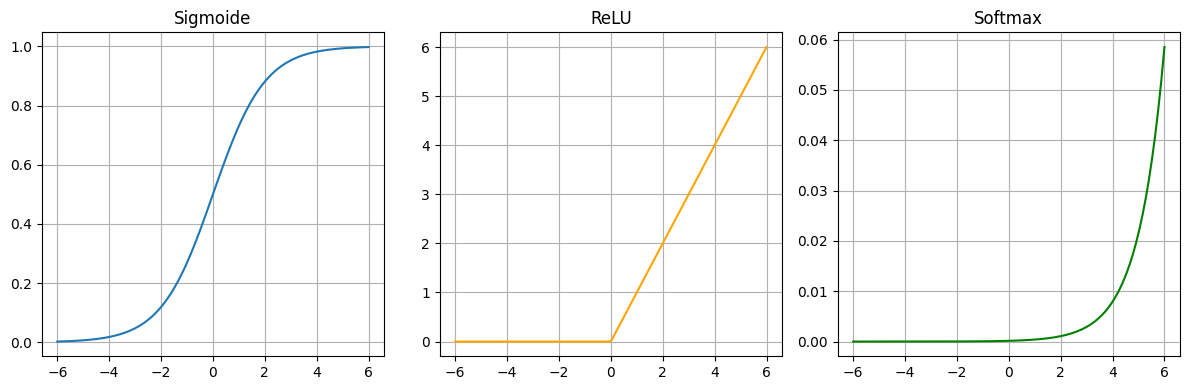

In [45]:
import numpy as np
import matplotlib.pyplot as plt

# Rango de valores
z = np.linspace(-6, 6, 200)

# Funciones de activación
sigmoid = 1 / (1 + np.exp(-z))
relu = np.maximum(0, z)
softmax = np.exp(z) / np.sum(np.exp(z))  # aquí 1D, pero en práctica es sobre un vector

# Graficar
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(z, sigmoid, label="Sigmoide")
plt.title("Sigmoide")
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(z, relu, label="ReLU", color="orange")
plt.title("ReLU")
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(z, softmax, label="Softmax (1D)", color="green")
plt.title("Softmax")
plt.grid(True)

plt.tight_layout()
plt.show()